In [92]:
import os 
import pandas as pd 
import numpy as np
import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE

from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler

from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC

import joblib

In [4]:
df = pd.read_excel(r"C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLClassification_Project\data\input\default_of_credit_card_clients.xls",header=1)

In [5]:
df.drop('ID',axis=1,inplace=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

In [7]:
#dropping duplicates
df.drop_duplicates(inplace=True)


In [8]:
#renaming the columns
df.rename(columns={'PAY_0':'PAY_1'},inplace= True)

In [9]:
#missing values check
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [10]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,...,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,1.603738,1.853629,1.551877,35.487969,-0.016753,-0.131854,-0.164392,-0.218922,-0.264509,...,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014,0.221258
std,129760.135222,0.489128,0.790411,0.521997,9.219459,1.123492,1.196322,1.195878,1.168175,1.132220,...,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864,0.415101
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000


In [11]:
# checking target variable
df['default payment next month'].value_counts()

default payment next month
0    23335
1     6630
Name: count, dtype: int64

In [12]:
#replacing spaces with underscore
df.columns = df.columns.str.replace(" ", "_")

In [13]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()], 
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

num_summary=df.apply(var_summary).T 

In [14]:
num_summary

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
LIMIT_BAL,29965.0,0.0,5.017400e+09,167442.005006,140000.0,129760.135222,1.683769e+10,10000.0,10000.00,20000.0,30000.0,50000.0,140000.0,240000.0,360000.0,430000.0,500000.00,1000000.0
SEX,29965.0,0.0,4.805600e+04,1.603738,2.0,0.489128,2.392465e-01,1.0,1.00,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.00,2.0
EDUCATION,29965.0,0.0,5.554400e+04,1.853629,2.0,0.790411,6.247503e-01,0.0,1.00,1.0,1.0,1.0,2.0,2.0,3.0,3.0,5.00,6.0
MARRIAGE,29965.0,0.0,4.650200e+04,1.551877,2.0,0.521997,2.724805e-01,0.0,1.00,1.0,1.0,1.0,2.0,2.0,2.0,2.0,3.00,3.0
AGE,29965.0,0.0,1.063397e+06,35.487969,34.0,9.219459,8.499843e+01,21.0,22.00,23.0,25.0,28.0,34.0,41.0,49.0,53.0,60.00,79.0
PAY_1,29965.0,0.0,-5.020000e+02,-0.016753,0.0,1.123492,1.262234e+00,-2.0,-2.00,-2.0,-1.0,-1.0,0.0,0.0,2.0,2.0,3.00,8.0
PAY_2,29965.0,0.0,-3.951000e+03,-0.131854,0.0,1.196322,1.431186e+00,-2.0,-2.00,-2.0,-2.0,-1.0,0.0,0.0,2.0,2.0,3.00,8.0
PAY_3,29965.0,0.0,-4.926000e+03,-0.164392,0.0,1.195878,1.430123e+00,-2.0,-2.00,-2.0,-2.0,-1.0,0.0,0.0,2.0,2.0,3.00,8.0
PAY_4,29965.0,0.0,-6.560000e+03,-0.218922,0.0,1.168175,1.364633e+00,-2.0,-2.00,-2.0,-2.0,-1.0,0.0,0.0,2.0,2.0,3.00,8.0
PAY_5,29965.0,0.0,-7.926000e+03,-0.264509,0.0,1.132220,1.281922e+00,-2.0,-2.00,-2.0,-2.0,-1.0,0.0,0.0,0.0,2.0,3.00,8.0


In [15]:
#replacing invalid data values with other in EDUCATION
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6],4)

In [16]:
#replacing invalid data values with other in MARRIAGE
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [17]:
#encoding categorical columns 
df = pd.get_dummies(df, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True,dtype=int)

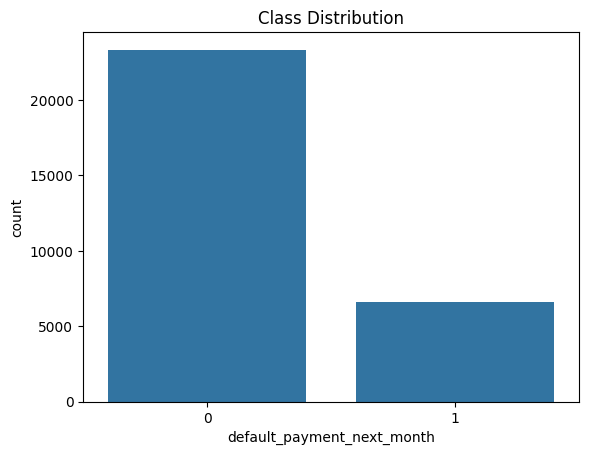

In [21]:
# checking distribution of target variables
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

In [20]:
# Seprating Target Varibale and Feature
X = df.drop('default_payment_next_month', axis=1)
y = df['default_payment_next_month']

In [22]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [23]:
#Standardizing Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df= pd.DataFrame(X_test, columns=X.columns)

In [25]:
#VIF
vif = pd.DataFrame()
vif["features"] = X_train_df.columns
vif["VIF Factor"] = [variance_inflation_factor(X_train_df.values, i) for i in range(X_train_df.shape[1])]


print(vif)

       features  VIF Factor
0     LIMIT_BAL    1.585239
1           AGE    1.382061
2         PAY_1    1.897776
3         PAY_2    3.118762
4         PAY_3    3.605491
5         PAY_4    4.203445
6         PAY_5    4.654637
7         PAY_6    3.236579
8     BILL_AMT1   15.164063
9     BILL_AMT2   27.914914
10    BILL_AMT3   21.686734
11    BILL_AMT4   18.682916
12    BILL_AMT5   24.197835
13    BILL_AMT6   14.710328
14     PAY_AMT1    1.545257
15     PAY_AMT2    2.463486
16     PAY_AMT3    1.602909
17     PAY_AMT4    1.628150
18     PAY_AMT5    1.718924
19     PAY_AMT6    1.176777
20        SEX_2    1.026407
21  EDUCATION_2    1.365180
22  EDUCATION_3    1.407752
23  EDUCATION_4    1.040160
24   MARRIAGE_2    1.326994
25   MARRIAGE_3    1.024190


In [26]:
#using only features with less vif
drop_cols = ["BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5"]

X_train_vif = X_train_df.drop(columns=drop_cols)
X_test_vif = X_test_df.drop(columns=drop_cols)

In [27]:
#using RFE on vif fatures 
rf = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=15)
rfe = RFE(estimator=rf, n_features_to_select=15)
rfe.fit(X_train_vif, y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",15
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [28]:
X_train_rfe = rfe.transform(X_train_vif)
X_test_rfe = rfe.transform(X_test_vif)

In [29]:
selected_features = X_train_vif.columns[rfe.support_]
print(selected_features)

Index(['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_6',
       'BILL_AMT1', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='str')


In [30]:
X_train_final = X_train_vif[selected_features]
X_test_final = X_test_vif[selected_features]

1) Logistic Regression Model

In [31]:
# Initializing and fitting the model on train data
LR_model = LogisticRegression(class_weight='balanced',max_iter=1000)
LR_model.fit(X_train_final, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [32]:
# Train report
print(classification_report(y_train, LR_model.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.88      0.71      0.78     15669
           1       0.38      0.64      0.48      4407

    accuracy                           0.69     20076
   macro avg       0.63      0.68      0.63     20076
weighted avg       0.77      0.69      0.72     20076



In [33]:
# Test report
print(classification_report(y_test, LR_model.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79      7666
           1       0.39      0.62      0.48      2223

    accuracy                           0.70      9889
   macro avg       0.63      0.67      0.64      9889
weighted avg       0.76      0.70      0.72      9889



2) KNN Classifier

In [34]:
#to address imbalace in class for KNN
smote = SMOTE(random_state=42)

X_train_final_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

In [35]:
# Initializing and fitting the model on train data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_final_sm,y_train_sm )

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [36]:
# train report
print(classification_report(y_train_sm, knn.predict(X_train_final_sm)))

              precision    recall  f1-score   support

           0       0.96      0.77      0.85     15669
           1       0.81      0.96      0.88     15669

    accuracy                           0.87     31338
   macro avg       0.88      0.87      0.87     31338
weighted avg       0.88      0.87      0.87     31338



In [37]:
# test report
print(classification_report(y_test, knn.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.86      0.69      0.77      7666
           1       0.36      0.61      0.46      2223

    accuracy                           0.67      9889
   macro avg       0.61      0.65      0.61      9889
weighted avg       0.75      0.67      0.70      9889



3) Naive Bayes

In [38]:
# Initializing and fitting the model on train data
nb = GaussianNB(priors=[0.5, 0.5])
nb.fit(X_train_final, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.","[0.5, 0.5]"
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [39]:
# train report
print(classification_report(y_train, nb.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.90      0.24      0.37     15669
           1       0.25      0.91      0.39      4407

    accuracy                           0.38     20076
   macro avg       0.57      0.57      0.38     20076
weighted avg       0.76      0.38      0.38     20076



In [40]:
# test report
print(classification_report(y_test, nb.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.89      0.23      0.37      7666
           1       0.26      0.91      0.40      2223

    accuracy                           0.38      9889
   macro avg       0.57      0.57      0.38      9889
weighted avg       0.75      0.38      0.38      9889



4) Decision Tree

In [41]:
#to address imbalace in class for Decision Tree
smote = SMOTE(random_state=42)

X_train_final_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

In [69]:
# Initializing and fitting the model on train data
dt = DecisionTreeClassifier(max_depth=5,min_samples_split=10,min_samples_leaf=5,random_state=42)
dt.fit(X_train_final, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [70]:
# train report
print(classification_report(y_train, dt.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89     15669
           1       0.69      0.38      0.49      4407

    accuracy                           0.83     20076
   macro avg       0.77      0.66      0.69     20076
weighted avg       0.81      0.83      0.81     20076



In [71]:
# test report
print(classification_report(y_test, dt.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      7666
           1       0.68      0.36      0.47      2223

    accuracy                           0.82      9889
   macro avg       0.76      0.66      0.68      9889
weighted avg       0.80      0.82      0.80      9889



5) Random Forest 

In [45]:
# Initializing and fitting the model on train data
rf = RandomForestClassifier( n_estimators=100,max_depth=5,min_samples_split=10,min_samples_leaf=5,class_weight='balanced',random_state=42)
rf.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [46]:
# train report
print(classification_report(y_train, rf.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85     15669
           1       0.49      0.62      0.55      4407

    accuracy                           0.78     20076
   macro avg       0.69      0.72      0.70     20076
weighted avg       0.80      0.78      0.79     20076



In [47]:
# test report
print(classification_report(y_test, rf.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7666
           1       0.50      0.59      0.54      2223

    accuracy                           0.78      9889
   macro avg       0.69      0.71      0.70      9889
weighted avg       0.79      0.78      0.78      9889



6) GradientBoost

In [48]:
#to address imbalace in class for Gradient Boost
smote = SMOTE(random_state=42)

X_train_final_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

In [49]:
# Initializing and fitting the model on train data
gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,min_samples_split=10,min_samples_leaf=5,random_state=42)
gb.fit(X_train_final_sm, y_train_sm)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [50]:
# train report
print(classification_report(y_train_sm, gb.predict(X_train_final_sm)))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81     15669
           1       0.84      0.73      0.78     15669

    accuracy                           0.80     31338
   macro avg       0.80      0.80      0.80     31338
weighted avg       0.80      0.80      0.80     31338



In [51]:
# test report
print(classification_report(y_test, gb.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      7666
           1       0.54      0.53      0.53      2223

    accuracy                           0.79      9889
   macro avg       0.70      0.70      0.70      9889
weighted avg       0.79      0.79      0.79      9889



7) XGBoost

In [52]:
# to address imbalace data in XGBOOST
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [53]:
# Initializing and fitting the model on train data
xgb = XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,scale_pos_weight=scale_pos_weight,random_state=42,use_label_encoder=False,eval_metric='logloss')
xgb.fit(X_train_final, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [54]:
# train report
print(classification_report(y_train, xgb.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84     15669
           1       0.47      0.66      0.55      4407

    accuracy                           0.76     20076
   macro avg       0.68      0.73      0.70     20076
weighted avg       0.80      0.76      0.78     20076



In [55]:
# test report
print(classification_report(y_test, xgb.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      7666
           1       0.47      0.62      0.54      2223

    accuracy                           0.76      9889
   macro avg       0.68      0.71      0.69      9889
weighted avg       0.79      0.76      0.77      9889



8) LightGBM

In [56]:
# Initializing and fitting the model on train data
lgbm = LGBMClassifier(n_estimators=300,learning_rate=0.03,max_depth=8,num_leaves=50,class_weight='balanced',random_state=42)
lgbm.fit(X_train_final, y_train)

[LightGBM] [Info] Number of positive: 4407, number of negative: 15669
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2223
[LightGBM] [Info] Number of data points in the train set: 20076, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,boosting_type,'gbdt'
,num_leaves,50
,max_depth,8
,learning_rate,0.03
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [57]:
# train report
print(classification_report(y_train, lgbm.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     15669
           1       0.58      0.77      0.66      4407

    accuracy                           0.83     20076
   macro avg       0.75      0.80      0.77     20076
weighted avg       0.85      0.83      0.83     20076



In [58]:
# test report
print(classification_report(y_test, lgbm.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      7666
           1       0.49      0.60      0.54      2223

    accuracy                           0.77      9889
   macro avg       0.69      0.71      0.69      9889
weighted avg       0.79      0.77      0.78      9889



8) CatBoost

In [59]:
# to handle class imbalance in CatBoost
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [60]:
# Initializing and fitting the model on train data
cat = CatBoostClassifier(iterations=300,learning_rate=0.05,depth=6,scale_pos_weight=scale_pos_weight,eval_metric='F1',random_state=42,verbose=0)
cat.fit(X_train_final, y_train)

CatBoostClassifier(depth=6, eval_metric='F1', iterations=300, learning_rate=0.05, random_state=42, scale_pos_weight=3.555479918311777, verbose=0)

In [61]:
# train report
print(classification_report(y_train, cat.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.90      0.81      0.86     15669
           1       0.51      0.69      0.59      4407

    accuracy                           0.79     20076
   macro avg       0.71      0.75      0.72     20076
weighted avg       0.82      0.79      0.80     20076



In [62]:
# test report
print(classification_report(y_test, cat.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      7666
           1       0.49      0.61      0.55      2223

    accuracy                           0.77      9889
   macro avg       0.69      0.71      0.70      9889
weighted avg       0.79      0.77      0.78      9889



9) Support Vector Machines

In [63]:
# Initializing and fitting the model on train data
svm = SVC(kernel='rbf', C=10, gamma=0.1, probability=True, class_weight='balanced',random_state=42)
svm.fit(X_train_final, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [64]:
# train report
print(classification_report(y_train, svm.predict(X_train_final)))

              precision    recall  f1-score   support

           0       0.90      0.83      0.87     15669
           1       0.54      0.68      0.60      4407

    accuracy                           0.80     20076
   macro avg       0.72      0.76      0.73     20076
weighted avg       0.82      0.80      0.81     20076



In [65]:
# test report
print(classification_report(y_test, svm.predict(X_test_final)))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      7666
           1       0.48      0.56      0.52      2223

    accuracy                           0.76      9889
   macro avg       0.67      0.69      0.68      9889
weighted avg       0.78      0.76      0.77      9889



“In the initial comparison of models, Logistic Regression achieved the highest recall, making it effective for detecting the positive class. However, ensemble models like LightGBM and CatBoost demonstrated better overall performance in terms of accuracy and F1-score.”

In [72]:
# Now using GridSearchCV on best models like:- Gradient Boosting,LightGBM,CatBoost 

GridSearch CV on LGBMClassifier

In [73]:
# imbalance handling
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [74]:
param_grid_lgbm = {'n_estimators': [100, 200],'learning_rate': [0.01, 0.05],'max_depth': [5, 7],'num_leaves': [31, 50]}
grid_lgbm = GridSearchCV(LGBMClassifier(random_state=42,scale_pos_weight=scale_pos_weight,feature_fraction = 0.8,bagging_fraction = 0.8),param_grid_lgbm,cv=3,scoring='f1',n_jobs=-1)

In [75]:
grid_lgbm.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 4407, number of negative: 15669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3271
[LightGBM] [Info] Number of data points in the train set: 20076, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.219516 -> initscore=-1.268490
[LightGBM] [Info] Start training from score -1.268490


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...5479918311777)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05], 'max_depth': [5, 7], 'n_estimators': [100, 200], 'num_leaves': [31, 50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [76]:
print(grid_lgbm.best_params_)

{'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 31}


In [77]:
best_lgbm = grid_lgbm.best_estimator_

In [78]:
print("Train Report:")
print(classification_report(y_train, best_lgbm.predict(X_train)))

print("Test Report:")
print(classification_report(y_test, best_lgbm.predict(X_test)))

Train Report:
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     15669
           1       0.54      0.61      0.57      4407

    accuracy                           0.80     20076
   macro avg       0.71      0.73      0.72     20076
weighted avg       0.81      0.80      0.80     20076

Test Report:
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      7666
           1       0.53      0.57      0.55      2223



GridSearch CV on CatBoostClassifier

In [79]:
#imbalace data handling
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
class_weights = [1, scale]

In [80]:
param_grid_cb = {'iterations': [200, 300],'learning_rate': [0.03, 0.05],'depth': [4, 6]}
grid_cb = GridSearchCV(CatBoostClassifier(random_state=42,verbose=0,scale_pos_weight=scale),param_grid_cb,cv=3,scoring='recall',n_jobs=-1)

In [81]:
grid_cb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...77, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6], 'iterations': [200, 300], 'learning_rate': [0.03, 0.05]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [82]:
print(grid_cb.best_params_)

{'depth': 4, 'iterations': 300, 'learning_rate': 0.03}


In [83]:
best_cb = grid_cb.best_estimator_

print("Train Report:")
print(classification_report(y_train, best_cb.predict(X_train)))

print("Test Report:")
print(classification_report(y_test, best_cb.predict(X_test)))

Train Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84     15669
           1       0.47      0.65      0.55      4407

    accuracy                           0.76     20076
   macro avg       0.68      0.72      0.69     20076
weighted avg       0.80      0.76      0.78     20076

Test Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      7666
           1       0.48      0.62      0.54      2223

    accuracy                           0.76      9889
   macro avg       0.68      0.71      0.69      9889
weighted avg       0.79      0.76      0.77      9889



“CatBoost provided the best balance between recall and F1-score, making it the most suitable model for handling class imbalance.”

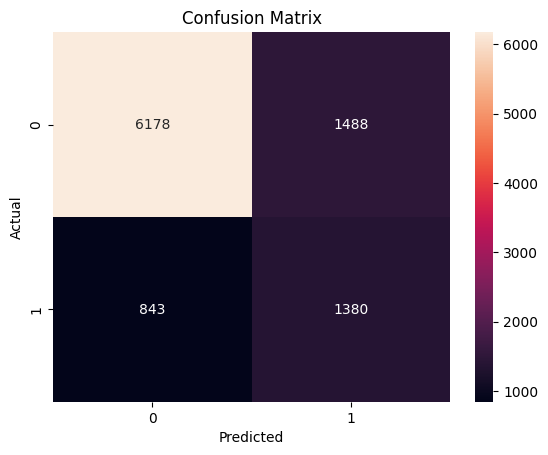

In [84]:
#Confusion Matrix for CatBoost 
y_pred = best_cb.predict(X_test)
cm = confusion_matrix(y_test,y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Heterogrnous modelling to further imrpove model performance on best two models (LightGBM,CatBoost)

In [85]:
ensemble = VotingClassifier(estimators=[('cb', best_cb),('lgbm', best_lgbm)],voting='soft',weights=[3, 2])  

ensemble.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Number of positive: 4407, number of negative: 15669
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001687 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3271
[LightGBM] [Info] Number of data points in the train set: 20076, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.219516 -> initscore=-1.268490
[LightGBM] [Info] Start training from score -1.268490


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cb', ...), ('lgbm', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[3, 2]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.01
,n_estimators,200


In [86]:
print(classification_report(y_train,ensemble.predict(X_train)))

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
              precision    recall  f1-score   support

           0       0.89      0.82      0.85     15669
           1       0.50      0.64      0.56      4407

    accuracy                           0.78     20076
   macro avg       0.69      0.73      0.70     20076
weighted avg       0.80      0.78      0.79     20076



In [87]:
print(classification_report(y_test,ensemble.predict(X_test)))

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      7666
           1       0.50      0.60      0.55      2223

    accuracy                           0.78      9889
   macro avg       0.69      0.72      0.70      9889
weighted avg       0.79      0.78      0.78      9889



[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


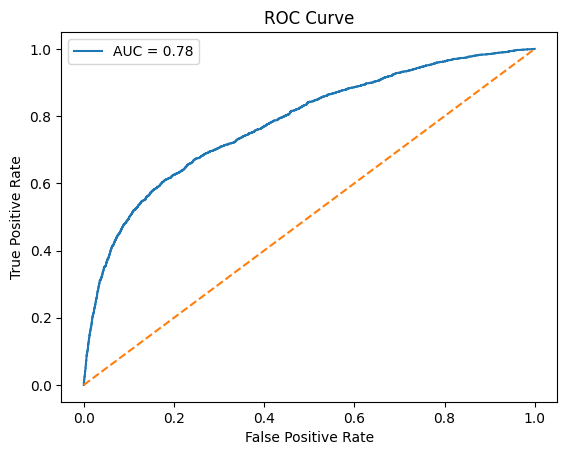

In [88]:
#ROC Curve on heterogenous model
y_proba = ensemble.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

“Although CatBoost achieved slightly higher recall, the ensemble model provided better overall performance in terms of accuracy and F1-score.”

In [89]:
# Performance summary of best models 
results = pd.DataFrame({
    'Model': ['LightGBM', 'CatBoost', 'Ensemble'],
    'Accuracy': [0.79, 0.76, 0.78],
    'Recall': [0.56, 0.62, 0.60],
    'F1 Score': [0.55, 0.54, 0.55]
})

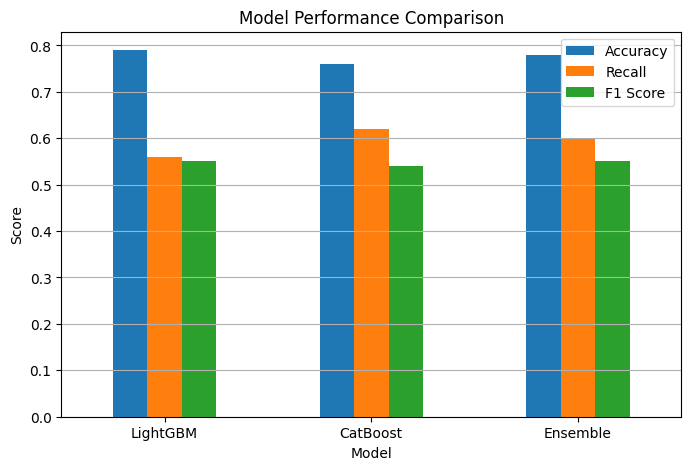

In [90]:
results.set_index('Model').plot(kind='bar', figsize=(8,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
# Saving the Model using joblib
joblib.dump({'model': ensemble,'features': X_train.columns.tolist()}, filename=r'C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLClassification_Project\data\output\pipeline_main1.pkl')